# Food Image Classification (UEC FOOD 100 subset)

主食・主菜・副菜・汁物の12品目を対象に、CNNで食品画像の分類を行います。
MNIST・銀河画像分類の演習と同じ流れ(データ読み込み → モデル構築 → 学習 → 評価)で進めます。

事前に `prepare_uecfood_classification_data.py` を実行し、`images/`, `train.csv`, `test.csv`, `class_map.csv` を
Google Drive にアップロードしておいてください。

## 1. Googleドライブのマウントとファイルの読み込み

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
import pandas as pd

# 環境に合わせて書き換えてください
dir_path = '/content/drive/MyDrive/Colab Notebooks/food_yolo/classification_data/' # ディレクトリパスに修正

df_train = pd.read_csv(dir_path + 'train.csv')
df_test = pd.read_csv(dir_path + 'test.csv')
df_class_map = pd.read_csv(dir_path + 'class_map.csv')

In [25]:
# 中身を確認
df_train

,file_name,label,label_name
0,36_15803_0.jpg,1,味噌汁
1,36_15154_0.jpg,1,味噌汁
2,87_14990_0.jpg,10,グリーンサラダ
3,1_31_0.jpg,0,ごはん
4,67_14711_0.jpg,7,卵焼き
...,...,...,...
2336,36_13840_0.jpg,1,味噌汁
2337,36_14764_0.jpg,1,味噌汁
2338,1_5073_0.jpg,0,ごはん
2339,1_14834_0.jpg,0,ごはん


In [26]:
# 品目一覧(12クラス)を確認
df_class_map

,label,label_name
0,0,ごはん
1,1,味噌汁
2,2,鮭の塩焼
3,3,鶏の唐揚げ
4,4,豚カツ
5,5,ハンバーグ
6,6,豚肉の生姜焼き
7,7,卵焼き
8,8,納豆
9,9,冷奴


## 2. 画像データの読み込み

In [27]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np

def load_images(df):
    images = []
    labels = []
    for _, row in df.iterrows():
        fname = dir_path + 'images/' + row['file_name']
        img = load_img(fname)
        img = img_to_array(img)
        images.append(img)
        labels.append(row['label'])
    return np.array(images), np.array(labels)

x_train, y_train = load_images(df_train)
x_test, y_test = load_images(df_test)

## 3. データサイズと次元の確認

In [29]:
print("訓練用画像の枚数、画素数、チャンネル数")
print(x_train.shape)
print("テスト用画像の枚数、画素数、チャンネル数")
print(x_test.shape)

訓練用画像の枚数、画素数、チャンネル数
(2341, 128, 128, 3)
テスト用画像の枚数、画素数、チャンネル数
(585, 128, 128, 3)


## 4. 画像の表示

/tmp/ipykernel_461/4040841419.py:10: UserWarning: Glyph 21619 (\N{CJK UNIFIED IDEOGRAPH-5473}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_461/4040841419.py:10: UserWarning: Glyph 22092 (\N{CJK UNIFIED IDEOGRAPH-564C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_461/4040841419.py:10: UserWarning: Glyph 27713 (\N{CJK UNIFIED IDEOGRAPH-6C41}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_461/4040841419.py:10: UserWarning: Glyph 12464 (\N{KATAKANA LETTER GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_461/4040841419.py:10: UserWarning: Glyph 12522 (\N{KATAKANA LETTER RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_461/4040841419.py:10: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_461/4040841419.py:10: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(

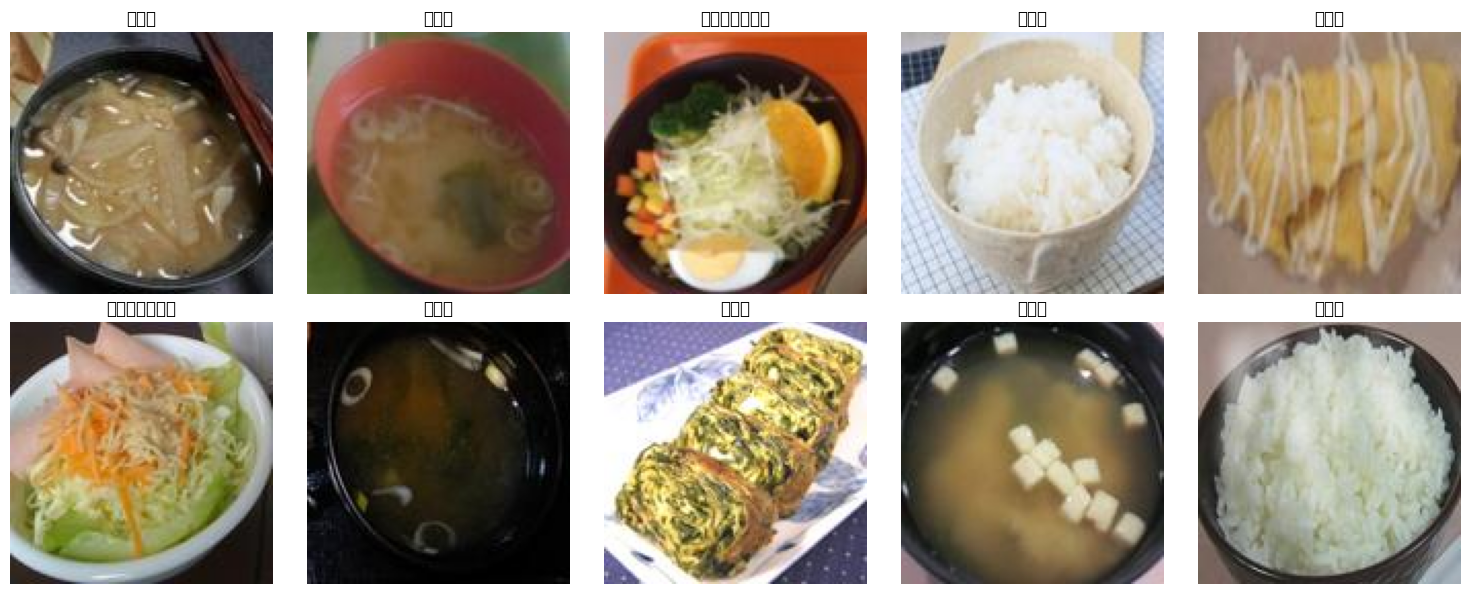

In [30]:
import matplotlib.pyplot as plt

class_names = dict(zip(df_class_map['label'], df_class_map['label_name']))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].astype('uint8'))
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. ラベルのone-hotエンコーディング

In [31]:
from tensorflow.keras.utils import to_categorical

num_classes = len(df_class_map)

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

## 6. モデルの構築(CNN)

In [32]:
from tensorflow.keras.models import Sequential

model = Sequential()

In [33]:
from tensorflow.keras.layers import Conv2D

# 畳み込み層(1)
model.add(Conv2D(filters=32, kernel_size=(3, 3), \
                 activation='relu', input_shape=(128, 128, 3)))

# 畳み込み層(2)
model.add(Conv2D(filters=64, kernel_size=(3, 3), \
                 activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
from tensorflow.keras.layers import MaxPooling2D

model.add(MaxPooling2D(pool_size=(2, 2)))

In [35]:
# 畳み込み層+プーリング層をもう1セット追加
model.add(Conv2D(filters=32, kernel_size=(3, 3), \
                 activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), \
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

In [36]:
from tensorflow.keras.layers import Dropout

model.add(Dropout(0.25))

In [37]:
from tensorflow.keras.layers import Flatten, Dense

model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.25))

In [38]:
# 出力層: 12クラス分類なのでsoftmax(銀河演習のsigmoidとは異なる点に注意)
model.add(Dense(units=num_classes, activation='softmax'))

## 7. モデルのコンパイル

In [39]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 53824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,889,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,947,500 (26.50 MB)

 Trainable params: 6,947,500 (26.50 MB)

 Non-trainable params: 0 (0.00 B)

## 8. 学習

In [42]:
epochs = 10

results = model.fit(x_train, y_train_cat, epochs=epochs, \
                    validation_data=(x_test, y_test_cat))

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.9265 - loss: 0.2381 - val_accuracy: 0.6051 - val_loss: 2.0110
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - accuracy: 0.9368 - loss: 0.2001 - val_accuracy: 0.5983 - val_loss: 1.6657
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.9381 - loss: 0.2059 - val_accuracy: 0.5915 - val_loss: 1.6422
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.9569 - loss: 0.1509 - val_accuracy: 0.6051 - val_loss: 1.8309
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.9705 - loss: 0.0962 - val_accuracy: 0.6051 - val_loss: 1.9877
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.9722 - loss: 0.0939 - val_accuracy: 0.6085 - val_loss: 1.9917
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 264s 3s/step - accuracy: 0.9688 - loss: 0.0931 - val_accuracy: 0.6137 - val_loss: 2.0773
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - accuracy: 0.9701 - loss: 0.0904 - val_accuracy: 0.6051 - v

## 9. 学習履歴の表示

In [48]:
!pip install japanize-matplotlib --quiet
import japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 52.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


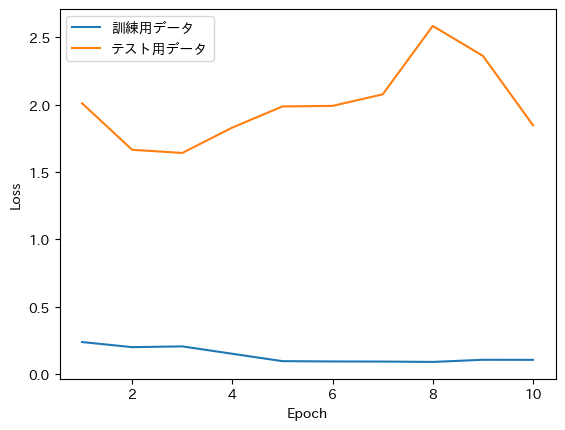

In [49]:
epo = range(1, epochs + 1)

fig, ax = plt.subplots()
ax.plot(epo, results.history["loss"], label="訓練用データ")
ax.plot(epo, results.history["val_loss"], label="テスト用データ")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

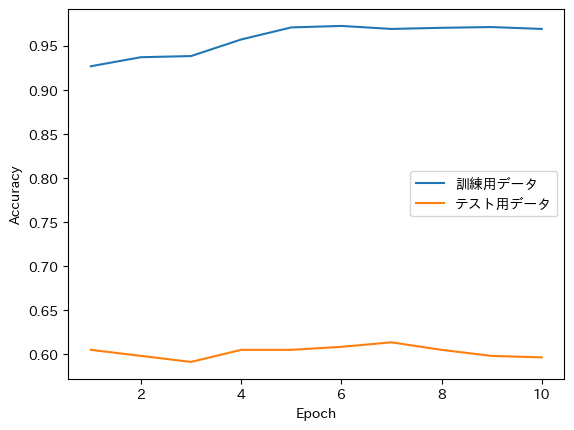

In [50]:
fig, ax = plt.subplots()
ax.plot(epo, results.history["accuracy"], label="訓練用データ")
ax.plot(epo, results.history["val_accuracy"], label="テスト用データ")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
plt.show()

## 10. 予測

In [45]:
y_pred = model.predict(x_test)
y_pred_label = np.argmax(y_pred, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 792ms/step


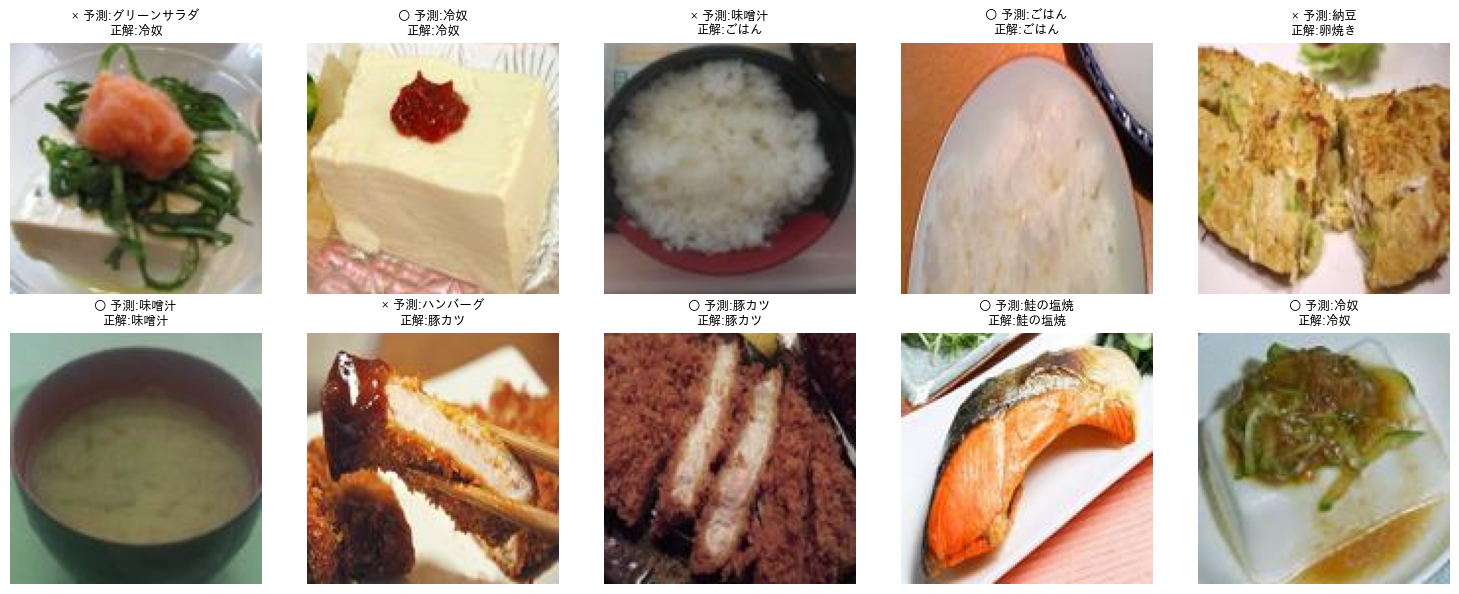

In [51]:
# テスト画像といくつかの予測結果を表示
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].astype('uint8'))
    correct = "○" if y_pred_label[i] == y_test[i] else "×"
    ax.set_title(f"{correct} 予測:{class_names[y_pred_label[i]]}\n正解:{class_names[y_test[i]]}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 11. 混同行列(Confusion Matrix)

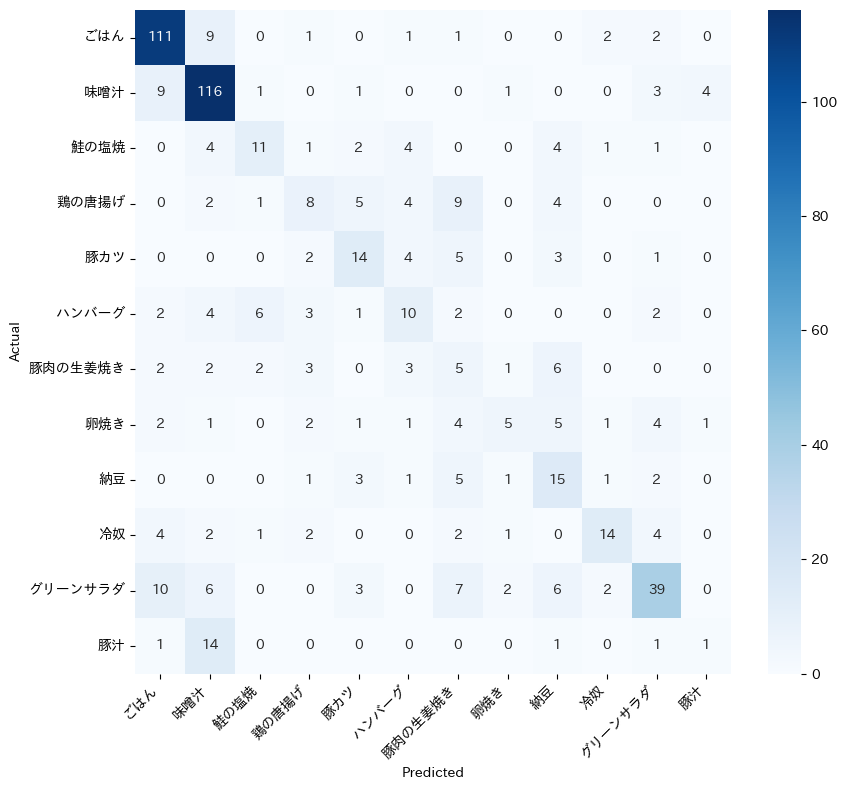

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_label)
label_names = [class_names[i] for i in range(num_classes)]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [54]:
import pandas as pd
train_df = pd.read_csv(dir_path + 'train.csv')
print(train_df['label_name'].value_counts())

label_name
味噌汁        596
ごはん        499
グリーンサラダ    275
冷奴         129
鶏の唐揚げ      121
納豆         118
豚カツ        111
ハンバーグ      106
卵焼き        104
豚汁         101
豚肉の生姜焼き     93
鮭の塩焼        88
Name: count, dtype: int64
